# Bytewise Fellowship Week 7

# Dataset : Wholesale Customers Dataset
## K-Means Clustering for Customer Segmentation

- **Task: 1**
    - Use K-Means clustering to segment customers in the Wholesale Customers dataset based on their annual spending in different categories. Visualize the clusters.

    - Evaluating the Optimal Number of Clusters

- **Task: 2**
    - Determine the optimal number of clusters for the Wholesale Customers dataset using the Elbow Method and Silhouette Score. Visualize the results and justify your choice.

    - Cluster Analysis and Interpretation

- **Task: 3**
    - Interpret the clusters formed in the Wholesale Customers dataset. Identify the characteristics and differences among the clusters based on spending behavior.

    - Hierarchical Clustering: Dendrogram and Cluster Formation

- **Task: 4**
    - Apply hierarchical clustering to the Wholesale Customers dataset and visualize the dendrogram. Compare the cluster assignments with those obtained from K-Means.

    - Comparison of Clustering Results

- **Task: 5**
    - Compare the effectiveness of K-Means and hierarchical clustering on the Wholesale Customers dataset. Discuss the results in terms of cluster cohesion and separation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans
plt.figure(figsize=(10, 7))
import warnings
warnings.filterwarnings('ignore')

<Figure size 1000x700 with 0 Axes>

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets /BWF_Week7_Dataset/Wholesale customers data.csv')  # Replace 'your_dataset.csv' with the actual file path

In [ ]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# Task 1

In [ ]:
# Select relevant features for clustering
X = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']]

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # You can start with 3 clusters
clusters = kmeans.fit_predict(X)

# Add the cluster labels to the dataset
df['Cluster'] = clusters


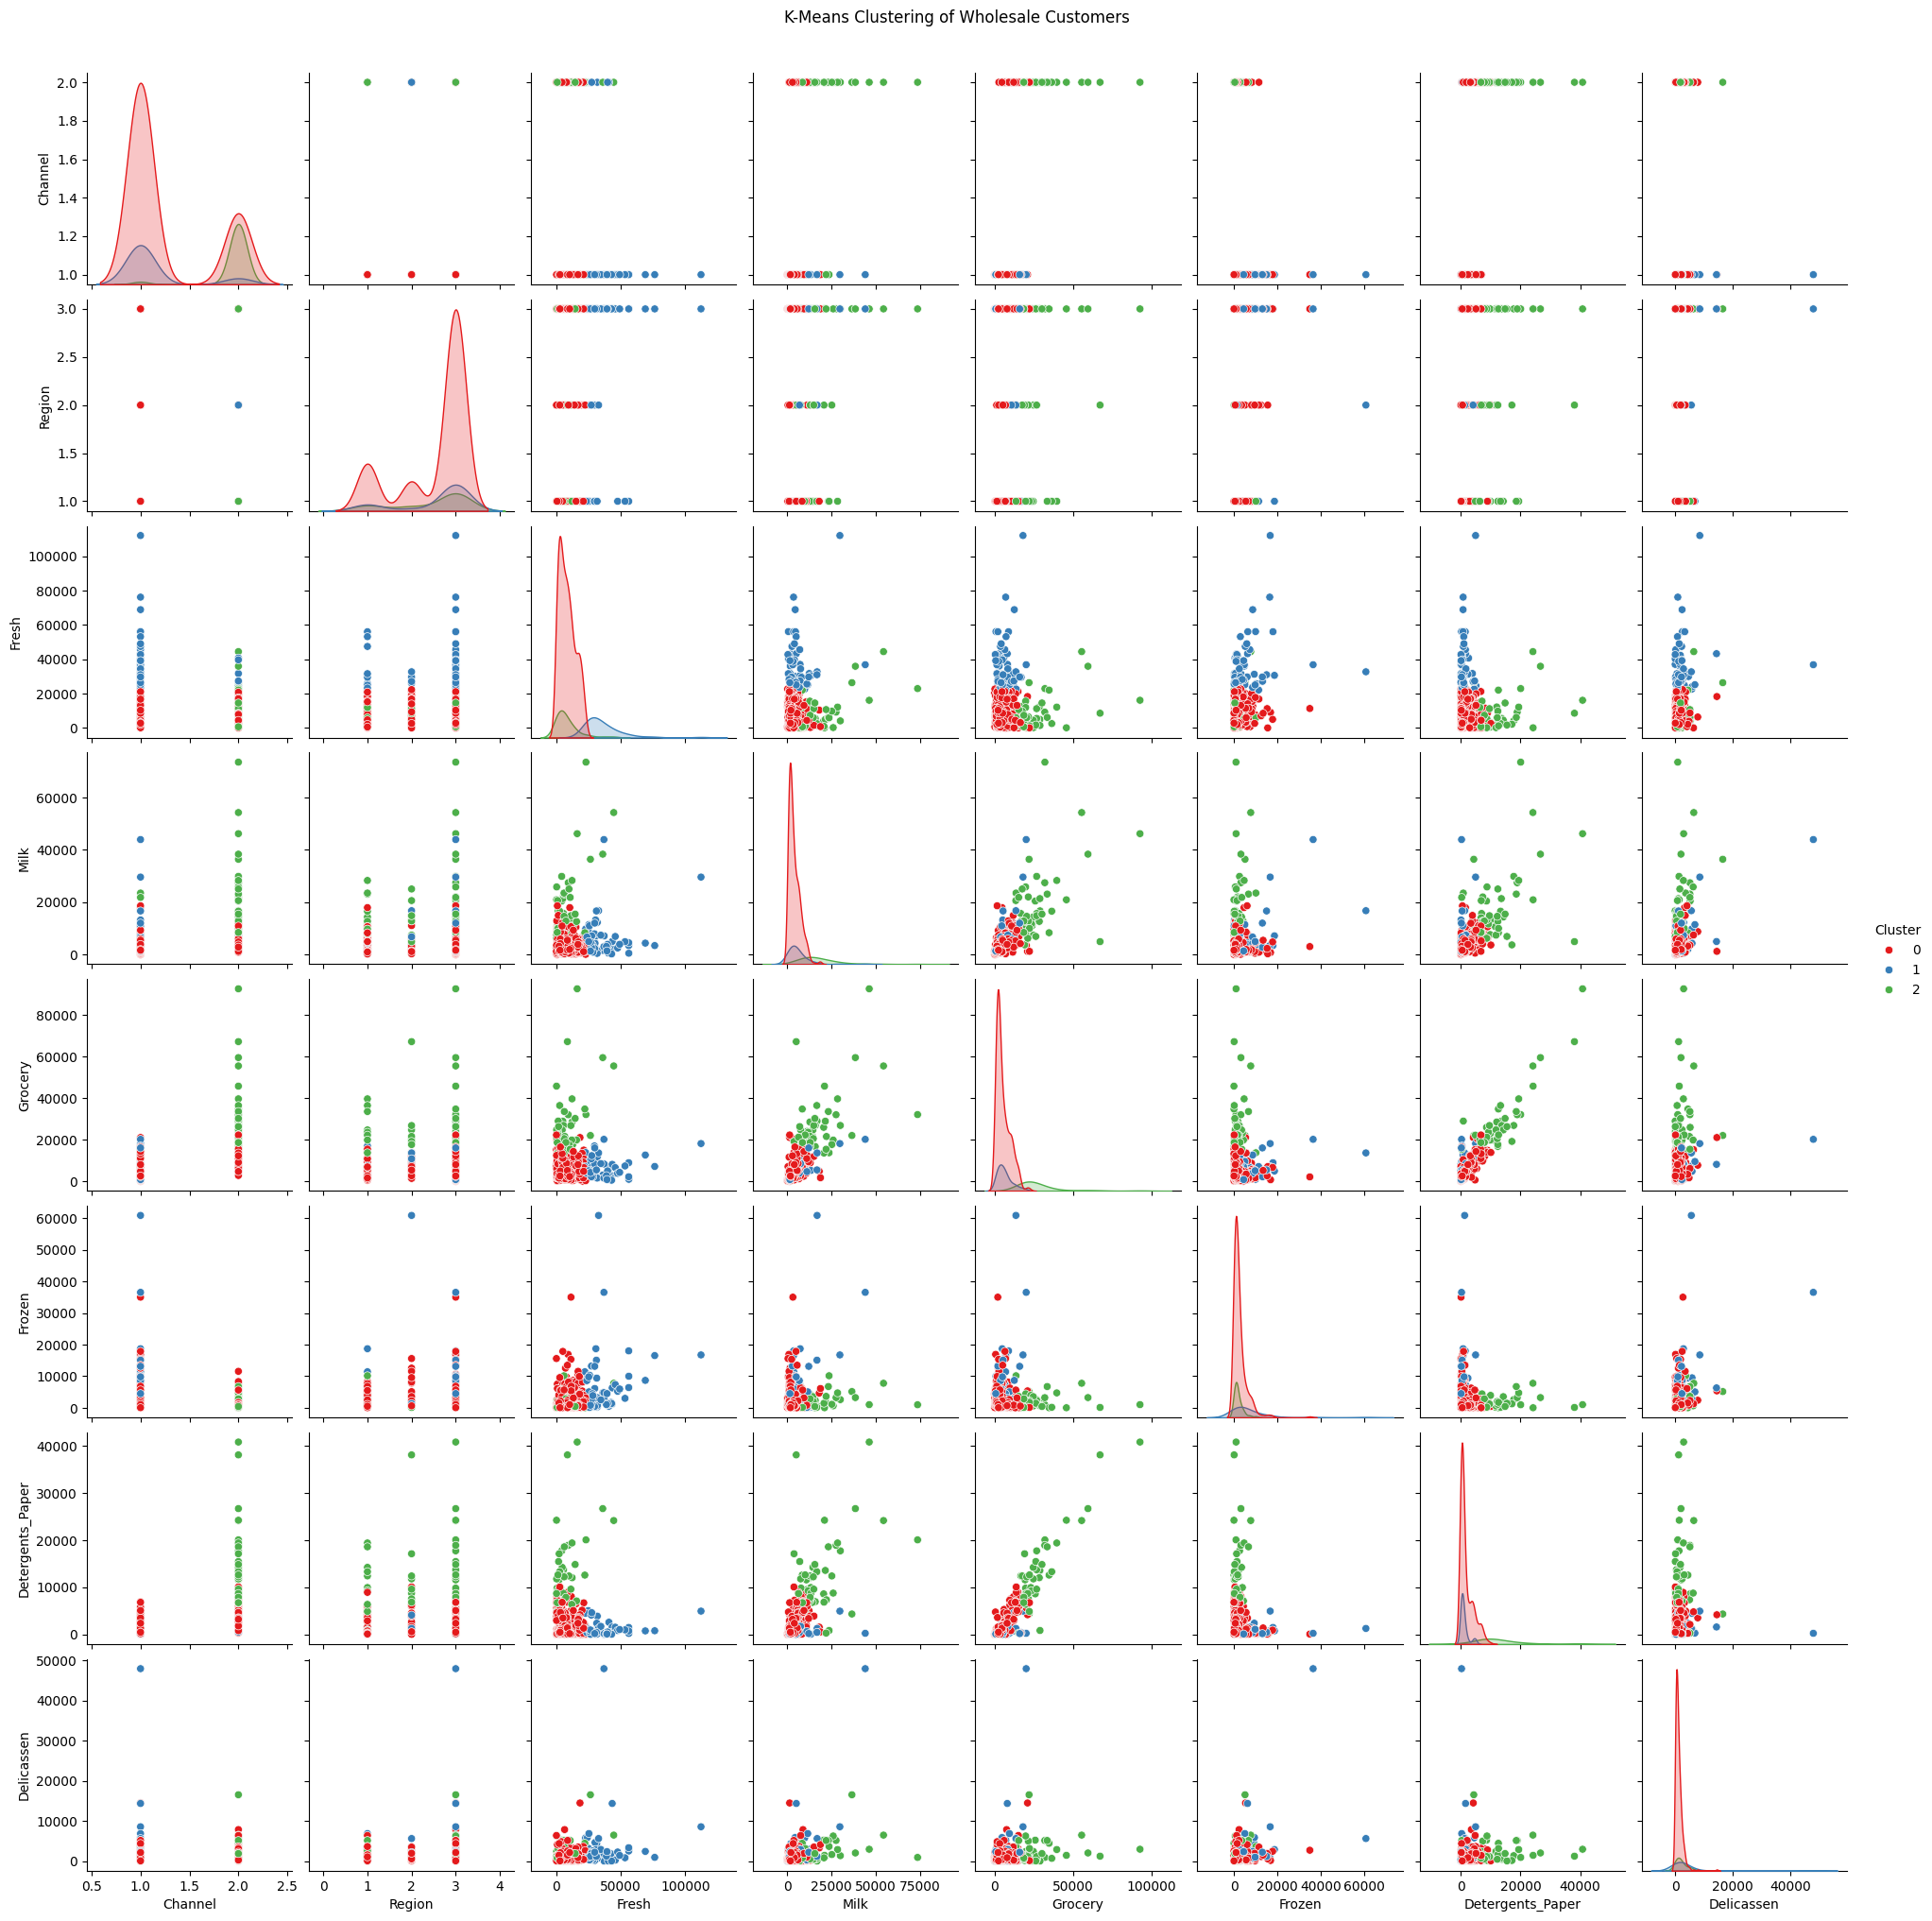

In [ ]:
# Visualize the clusters using a pairplot
sns.pairplot(df, hue='Cluster', palette='Set1')
plt.suptitle("K-Means Clustering of Wholesale Customers", y=1.02)  # Adding a title
plt.show()

# Task 2

### Evaluating the Optimal Number of Clusters

In [ ]:
# the optimal number of clusters using the Elbow Method
sse = []  # List to store the sum of squared errors for each k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # Append the SSE (inertia) for each k

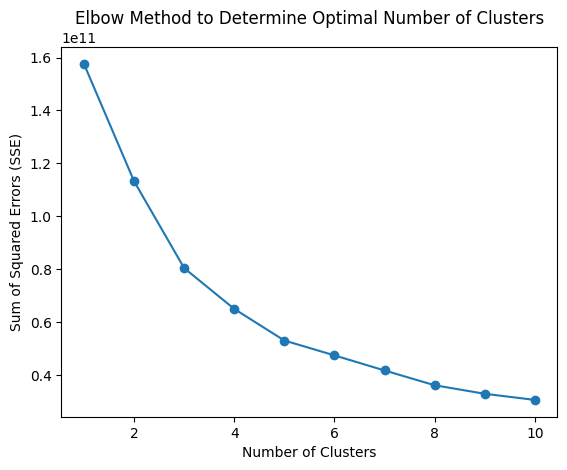

In [ ]:
# Plot the Elbow Method result
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score  # For calculating silhouette score

# Calculate Silhouette Scores for k = 2 to k = 10
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))


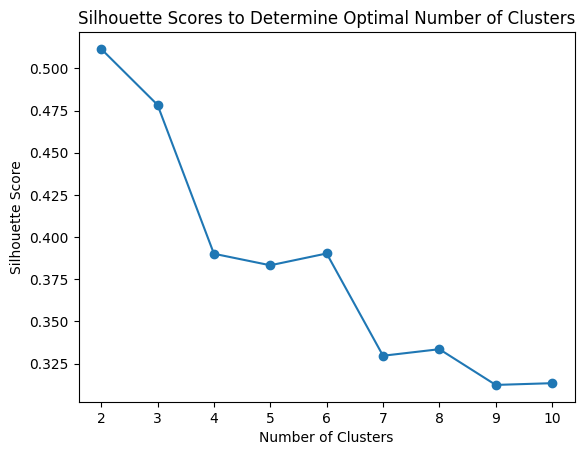

In [ ]:
# Plot the Silhouette Scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores to Determine Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

- **Elbow Method:** The elbow method helps determine the optimal number of clusters by identifying the point where adding more clusters doesn't significantly reduce the SSE.

- **Silhouette Score:** This score helps in identifying how well-separated the clusters are, with higher values indicating better-defined clusters.

# Task 3
### Interpret the Clusters from K-Means

In [ ]:
# Group the data by clusters and calculate the mean spending in each category
cluster_analysis = df.groupby('Cluster').mean()

# Display the mean spending in each cluster
print(cluster_analysis)


          Channel    Region         Fresh         Milk       Grocery  \
Cluster                                                                
0        1.260606  2.554545   8253.469697   3824.60303   5280.454545   
1        1.133333  2.566667  35941.400000   6044.45000   6288.616667   
2        1.960000  2.440000   8000.040000  18511.42000  27573.900000   

              Frozen  Detergents_Paper   Delicassen  
Cluster                                              
0        2572.660606       1773.057576  1137.496970  
1        6713.966667       1039.666667  3049.466667  
2        1996.680000      12407.360000  2252.020000  


### Visualize Spending Behavior Across Clusters

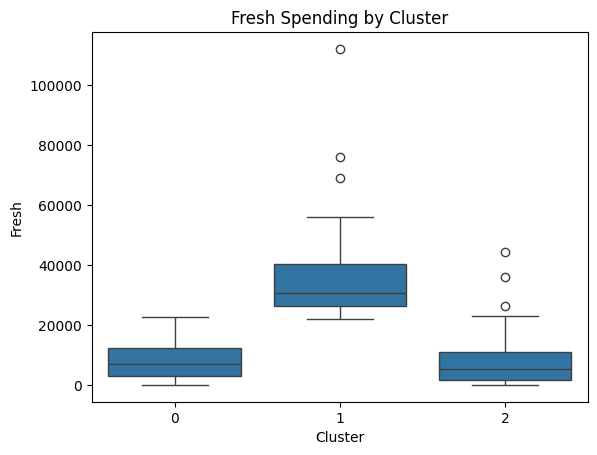

In [ ]:
# Visualize Fresh spending across clusters
sns.boxplot(x='Cluster', y='Fresh', data=df)
plt.title('Fresh Spending by Cluster')
plt.show()

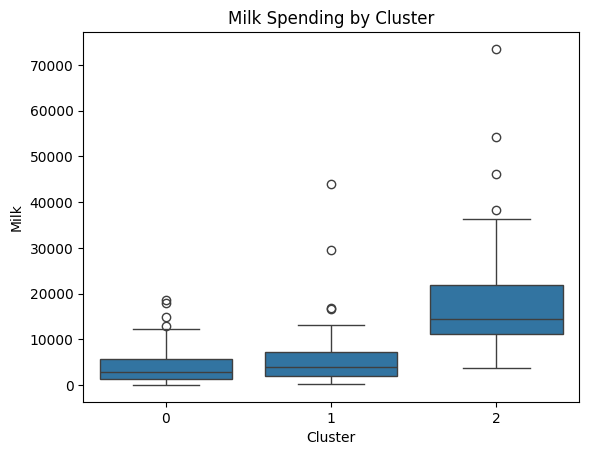

In [ ]:
# Repeat the boxplot for other features to understand spending behavior
sns.boxplot(x='Cluster', y='Milk', data=df)
plt.title('Milk Spending by Cluster')
plt.show()

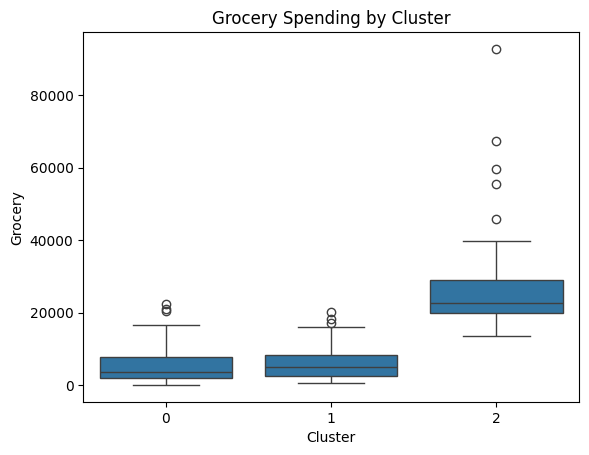

In [ ]:
sns.boxplot(x='Cluster', y='Grocery', data=df)
plt.title('Grocery Spending by Cluster')
plt.show()

### Hierarchical Clustering and Dendrogram

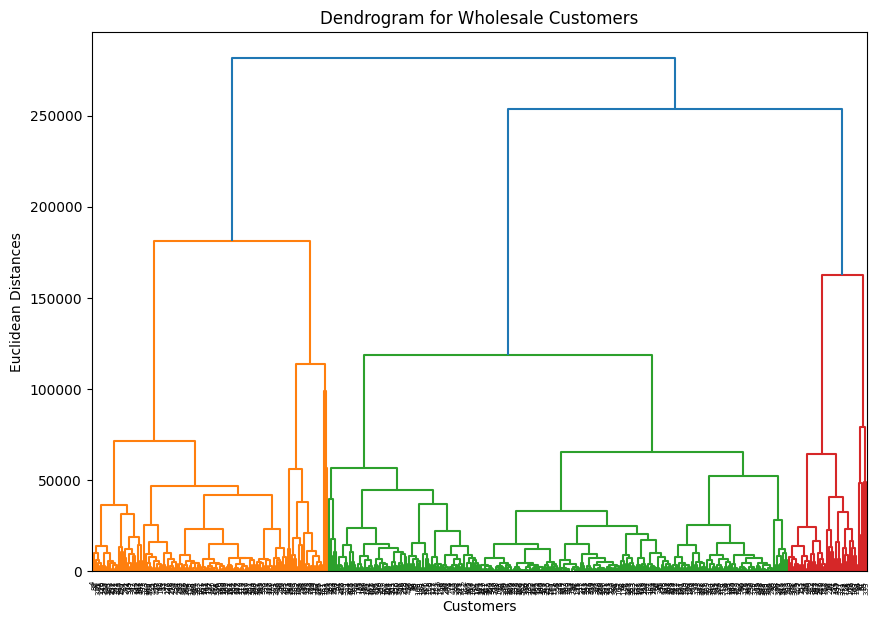

In [ ]:
import scipy.cluster.hierarchy as sch  # For creating dendrogram
from sklearn.cluster import AgglomerativeClustering  # For hierarchical clustering

# Generate the dendrogram to visualize how clusters are formed
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram for Wholesale Customers')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()


###  Form Clusters Using Hierarchical Clustering

In [ ]:
# Apply Agglomerative Clustering to form clusters
hc = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
hc_clusters = hc.fit_predict(X)

# Add the hierarchical cluster labels to the dataset
df['HC_Cluster'] = hc_clusters

# Display the dataset with hierarchical clusters
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,HC_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0,2
1,2,3,7057,9810,9568,1762,3293,1776,0,2
2,2,3,6353,8808,7684,2405,3516,7844,0,2
3,1,3,13265,1196,4221,6404,507,1788,0,2
4,2,3,22615,5410,7198,3915,1777,5185,1,0


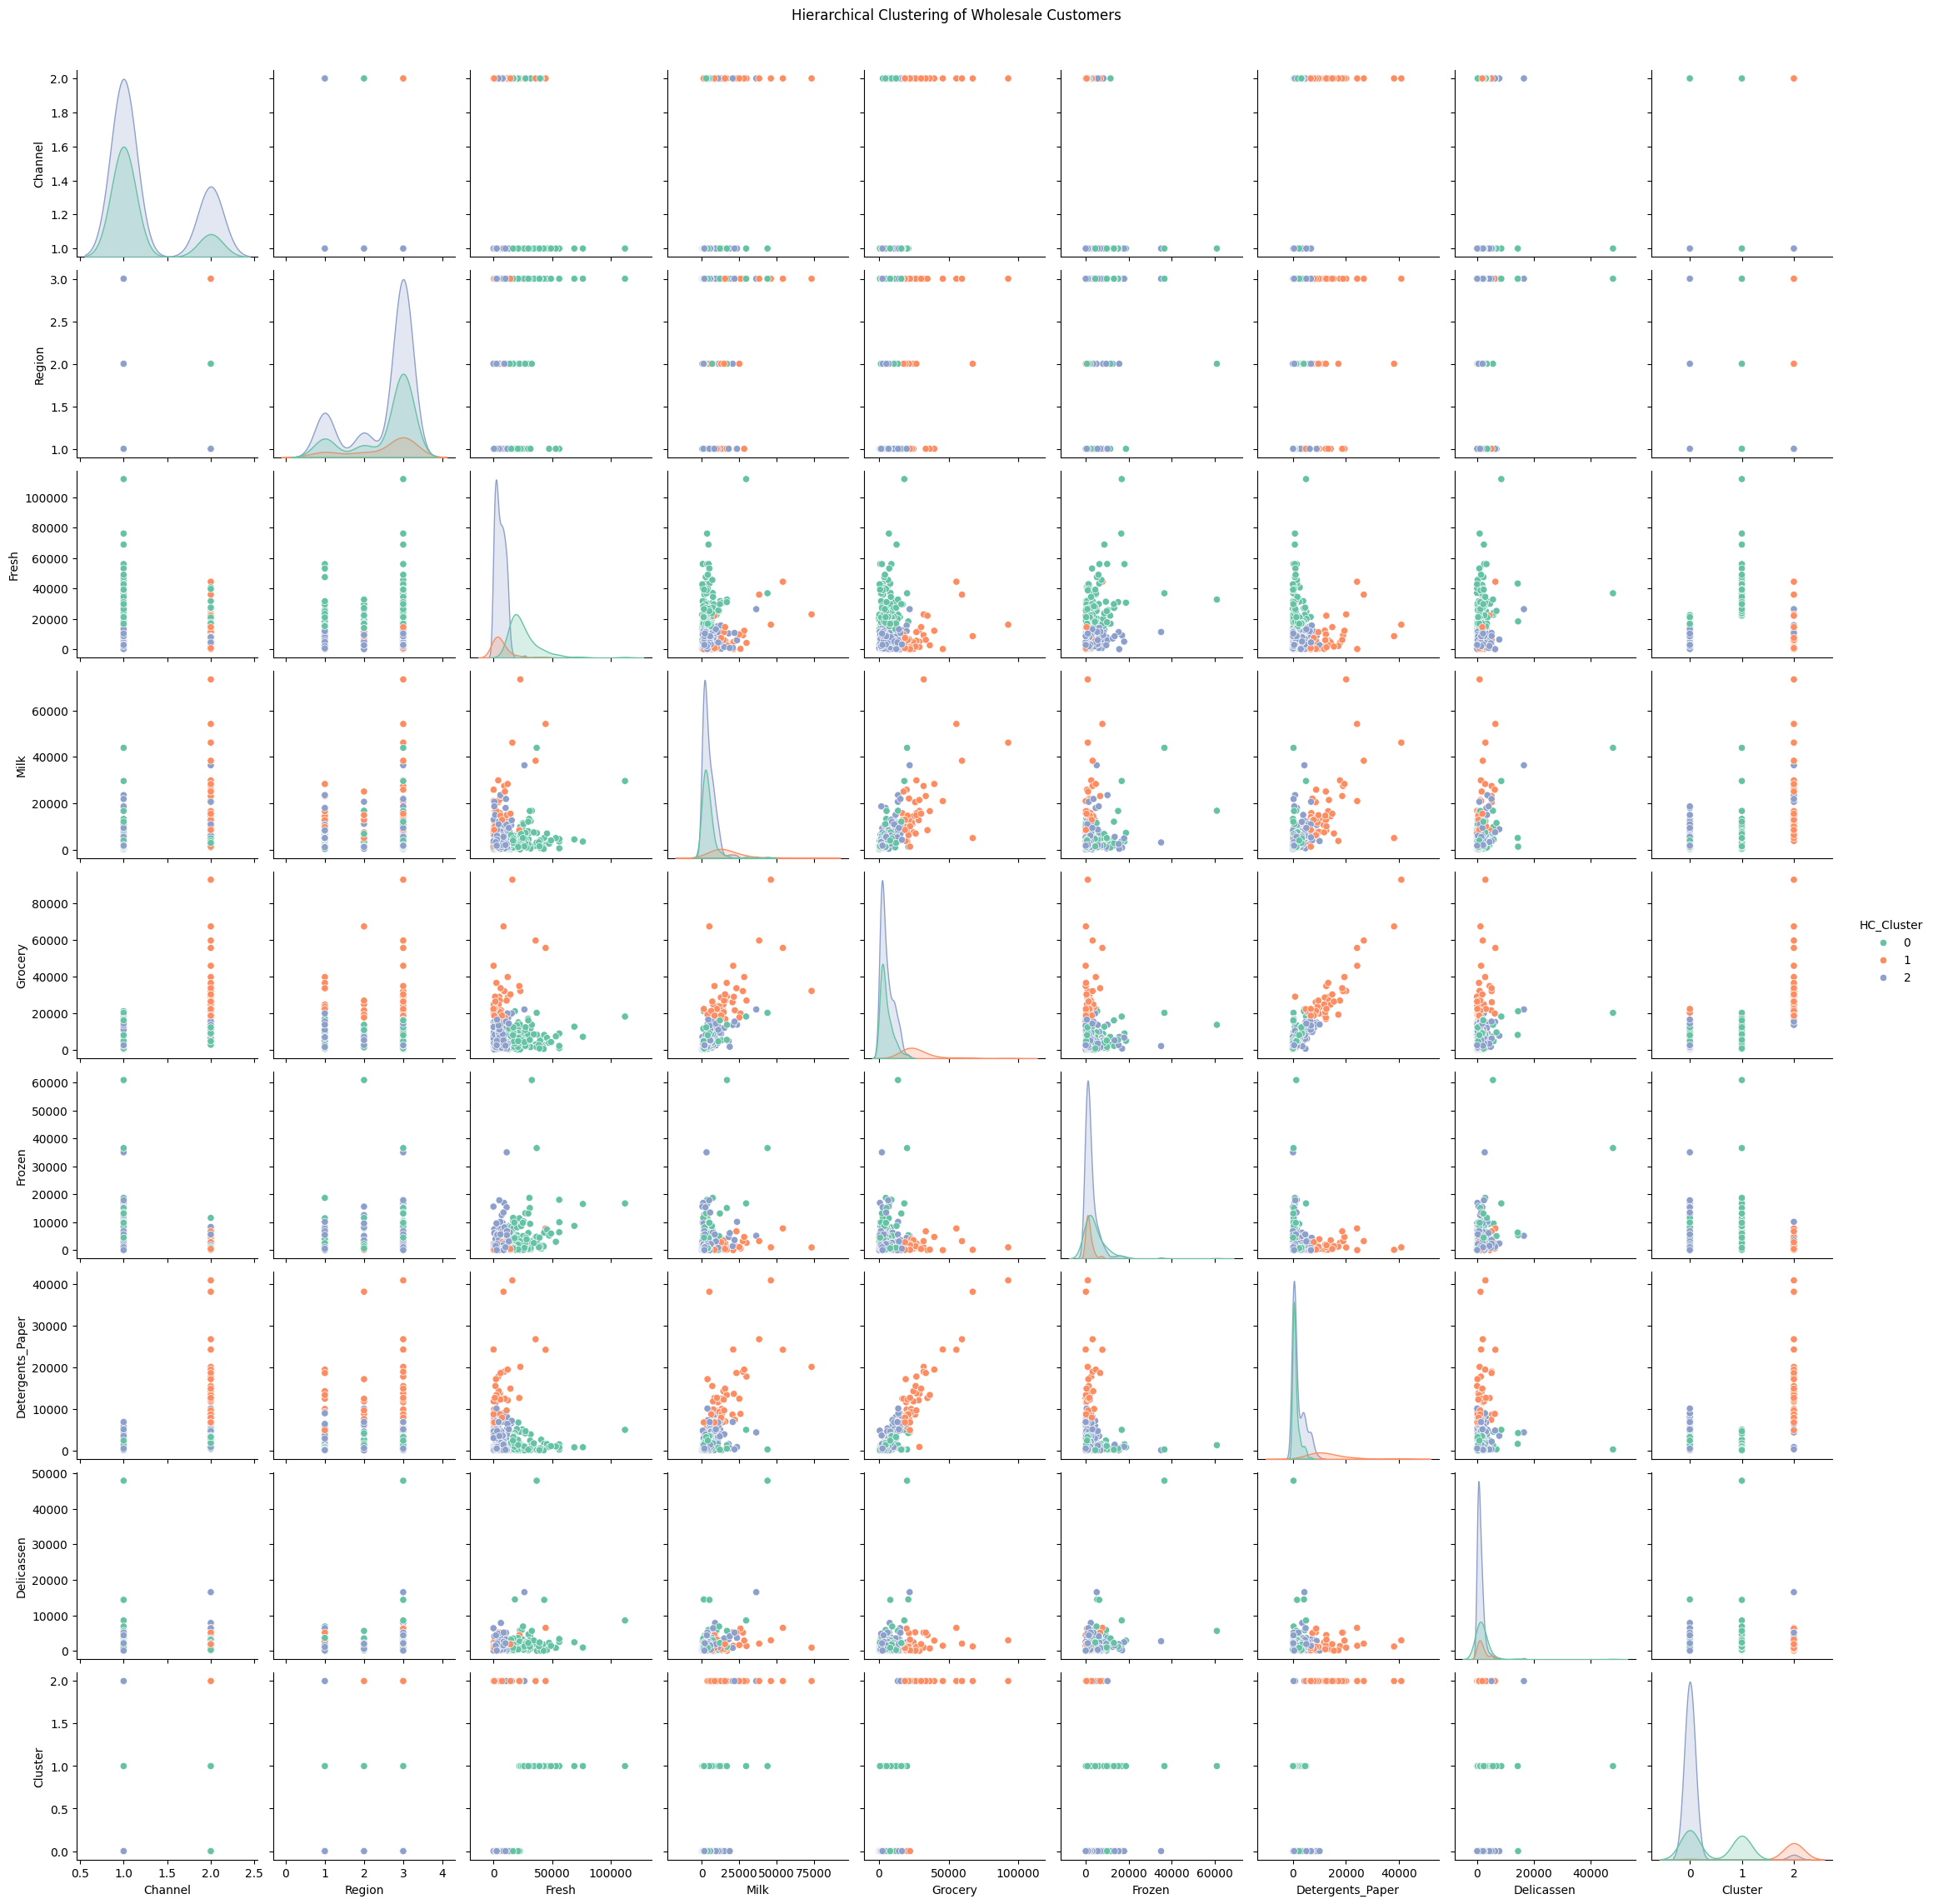

In [ ]:
# Visual comparison between K-Means and Hierarchical clustering
sns.pairplot(df, hue='HC_Cluster', palette='Set2')
plt.suptitle("Hierarchical Clustering of Wholesale Customers", y=1.02)
plt.show()


# Task 4

### Cluster Counts Comparison:

In [19]:
# Compare the number of customers in each cluster for both methods
print("K-Means Cluster Counts:")
print(df['Cluster'].value_counts())

print("Hierarchical Cluster Counts:")
print(df['HC_Cluster'].value_counts())

K-Means Cluster Counts:
Cluster
0    330
1     60
2     50
Name: count, dtype: int64
Hierarchical Cluster Counts:
HC_Cluster
2    261
0    134
1     45
Name: count, dtype: int64


In [20]:
# Calculate Silhouette Score for K-Means clustering
kmeans_silhouette = silhouette_score(X, df['Cluster'])
print(f"K-Means Silhouette Score: {kmeans_silhouette}")

# Calculate Silhouette Score for Hierarchical clustering
hc_silhouette = silhouette_score(X, df['HC_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {hc_silhouette}")

K-Means Silhouette Score: 0.4783511430782059
Hierarchical Clustering Silhouette Score: 0.37501552145375117


# Task 5


In [22]:
from sklearn.decomposition import PCA  # For dimensionality reduction

# Reduce the dataset to 2D using PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)


In [23]:
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]


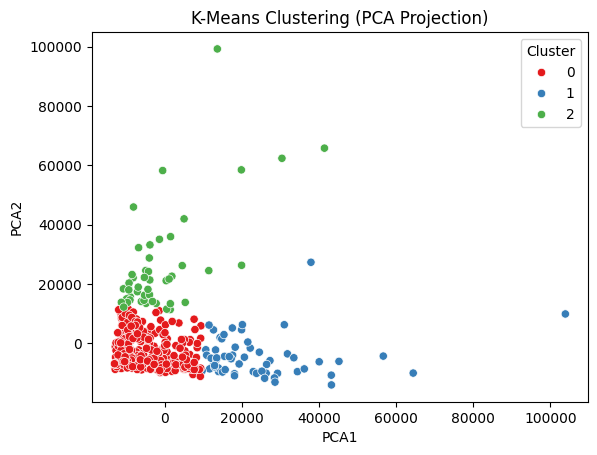

In [24]:
# Visualize the clusters formed by K-Means
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("K-Means Clustering (PCA Projection)")
plt.show()

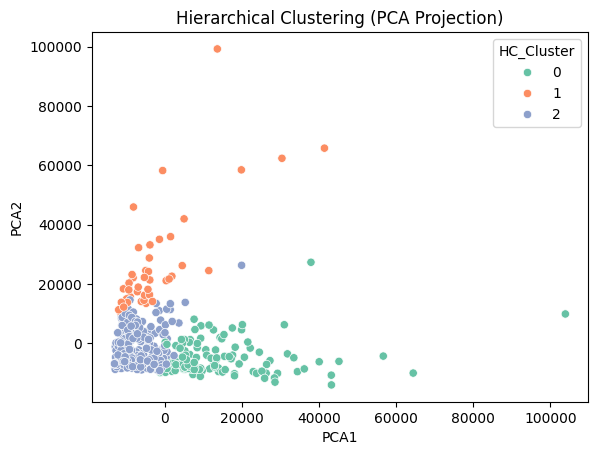

In [25]:
# Visualize the clusters formed by Hierarchical Clustering
sns.scatterplot(x='PCA1', y='PCA2', hue='HC_Cluster', data=df, palette='Set2')
plt.title("Hierarchical Clustering (PCA Projection)")
plt.show()

- K-Means: The silhouette score for K-Means clustering typically indicates how tightly the points are clustered around the cluster centroids. A higher silhouette score in K-Means suggests that the points within each cluster are more cohesive and well-separated from other clusters.
- Hierarchical Clustering: The silhouette score for hierarchical clustering indicates how well the algorithm groups similar points together based on the hierarchical structure. Hierarchical clustering might not always provide as high a silhouette score as K-Means because it doesn’t necessarily optimize for centroid-based cohesion.